In [1]:
# uncomment the below line and run this cell to install the large english model which is trained on wikipedia data

# !python -m spacy download en_core_web_lg

In [2]:
# import spacy and load the language model downloaded
import spacy

nlp = spacy.load("en_core_web_lg")

In [3]:
# import pandas library
import pandas as pd

# read the dataset "news_dataset.json" provided and load it into dataframe "df"
df = pd.read_json("./datasets/news.json")

# print the shape of data
print(df.shape)

# print the top5 rows
df

(7500, 2)


,text,category
0,"Larry Nassar Blames His Victims, Says He 'Was ...",CRIME
1,"Woman Beats Cancer, Dies Falling From Horse",CRIME
2,Vegas Taxpayers Could Spend A Record $750 Mill...,SPORTS
3,This Richard Sherman Interception Literally Sh...,SPORTS
4,7 Things That Could Totally Kill Weed Legaliza...,BUSINESS
...,...,...
7495,Sex Offender Registries Are Not Really Keeping...,CRIME
7496,'Stockbroker's Bible' Just Told Oil Industry T...,BUSINESS
7497,Want to Change It? Scale It!,BUSINESS
7498,"How To Make A Billion Dollar Drug In 1961, new...",BUSINESS


In [4]:
# check the distribution of labels
from collections import Counter

print(Counter(df["category"]))

Counter({'CRIME': 2500, 'SPORTS': 2500, 'BUSINESS': 2500})


In [5]:
# Add the new column "label_num" which gives a unique number to each of these labels
df["label_num"] = df["category"].map({"CRIME": 1, "SPORTS": 2, "BUSINESS": 0})

# check the results with top 5 rows
df

,text,category,label_num
0,"Larry Nassar Blames His Victims, Says He 'Was ...",CRIME,1
1,"Woman Beats Cancer, Dies Falling From Horse",CRIME,1
2,Vegas Taxpayers Could Spend A Record $750 Mill...,SPORTS,2
3,This Richard Sherman Interception Literally Sh...,SPORTS,2
4,7 Things That Could Totally Kill Weed Legaliza...,BUSINESS,0
...,...,...,...
7495,Sex Offender Registries Are Not Really Keeping...,CRIME,1
7496,'Stockbroker's Bible' Just Told Oil Industry T...,BUSINESS,0
7497,Want to Change It? Scale It!,BUSINESS,0
7498,"How To Make A Billion Dollar Drug In 1961, new...",BUSINESS,0


### **Preprocess the text**


In [6]:
# use this utility function to preprocess the text
# 1. Remove the stop words
# 2. Convert to base form using lemmatisation


def preprocess(text):
    doc = nlp(text)
    doc = [
        str(y.lemma_).lower()
        for y in doc
        if not y.is_stop and not y.is_punct and not y.is_space
    ]

    return " ".join(doc)

In [7]:
# create a new column "preprocessed_text" which store the clean form of given text [use apply and lambda function]
df["preprocessed_text"] = df["text"].apply(preprocess)

In [8]:
# print the top 5 rows
df

,text,category,label_num,preprocessed_text
0,"Larry Nassar Blames His Victims, Says He 'Was ...",CRIME,1,larry nassar blame victims say victimize newly...
1,"Woman Beats Cancer, Dies Falling From Horse",CRIME,1,woman beats cancer dies fall horse
2,Vegas Taxpayers Could Spend A Record $750 Mill...,SPORTS,2,vegas taxpayers spend record $ 750 million new...
3,This Richard Sherman Interception Literally Sh...,SPORTS,2,richard sherman interception literally shake w...
4,7 Things That Could Totally Kill Weed Legaliza...,BUSINESS,0,7 thing totally kill weed legalization buzz
...,...,...,...,...
7495,Sex Offender Registries Are Not Really Keeping...,CRIME,1,sex offender registries keep child safe proble...
7496,'Stockbroker's Bible' Just Told Oil Industry T...,BUSINESS,0,stockbroker bible tell oil industry accept dem...
7497,Want to Change It? Scale It!,BUSINESS,0,want change scale
7498,"How To Make A Billion Dollar Drug In 1961, new...",BUSINESS,0,billion dollar drug 1961 newspaper world run s...


In [9]:
# create a new column "vector" that store the vector representation of each pre-processed text
df["vector"] = df["preprocessed_text"].apply(lambda x: nlp(x).vector)

In [10]:
# print the top 5 rows
df

,text,category,label_num,preprocessed_text,vector
0,"Larry Nassar Blames His Victims, Says He 'Was ...",CRIME,1,larry nassar blame victims say victimize newly...,"[-0.3472573, 0.021758832, -0.2137525, -0.01718..."
1,"Woman Beats Cancer, Dies Falling From Horse",CRIME,1,woman beats cancer dies fall horse,"[-0.16791849, 0.43708333, 0.035527337, 0.01661..."
2,Vegas Taxpayers Could Spend A Record $750 Mill...,SPORTS,2,vegas taxpayers spend record $ 750 million new...,"[0.053351898, 0.08053064, -0.05101806, -0.1991..."
3,This Richard Sherman Interception Literally Sh...,SPORTS,2,richard sherman interception literally shake w...,"[-0.038867258, 0.28459162, 0.071352966, -0.045..."
4,7 Things That Could Totally Kill Weed Legaliza...,BUSINESS,0,7 thing totally kill weed legalization buzz,"[-0.20180944, 0.11867001, 0.0036708585, -0.189..."
...,...,...,...,...,...
7495,Sex Offender Registries Are Not Really Keeping...,CRIME,1,sex offender registries keep child safe proble...,"[-0.13533835, 0.07309661, -0.24237421, 0.05342..."
7496,'Stockbroker's Bible' Just Told Oil Industry T...,BUSINESS,0,stockbroker bible tell oil industry accept dem...,"[-0.14445566, 0.11641791, 0.07075033, 0.040282..."
7497,Want to Change It? Scale It!,BUSINESS,0,want change scale,"[-0.027821997, 0.3256, -0.14553966, -0.0047359..."
7498,"How To Make A Billion Dollar Drug In 1961, new...",BUSINESS,0,billion dollar drug 1961 newspaper world run s...,"[-0.08921791, 0.030023266, 0.08318581, 0.07975..."


In [11]:
from sklearn.model_selection import train_test_split

X = df["vector"]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [12]:
import numpy as np


# reshapes the X_train and X_test using 'stack' function of numpy. Store the result in new variables "X_train_2d" and "X_test_2d"
X_train_2d = np.stack(X_train)
X_test_2d = np.stack(X_test)

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# 1. creating a Decision Tree model object
dtc = DecisionTreeClassifier()

# 2. fit with all_train_embeddings and y_train
dtc.fit(X_train_2d, y_train)

# 3. get the predictions for all_test_embeddings and store it in y_pred
y_hat = dtc.predict(X_test_2d)

# 4. print the classfication report
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.77      0.77      0.77       500
           1       0.78      0.76      0.77       500
           2       0.74      0.75      0.75       500

    accuracy                           0.76      1500
   macro avg       0.76      0.76      0.76      1500
weighted avg       0.76      0.76      0.76      1500



In [14]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report


# doing scaling because Negative values will not pass into Naive Bayes models
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled = scaler.fit_transform(X_test_2d)

# 1. creating a MultinomialNB model object
nb = MultinomialNB()

# 2. fit with all_train_embeddings(scaled) and y_train
nb.fit(X_train_scaled, y_train)

# 3. get the predictions for all_test_embeddings and store it in y_pred
y_hat = nb.predict(X_test_scaled)

# 4. print the classfication report
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.82      0.95      0.88       500
           1       0.92      0.86      0.89       500
           2       0.92      0.82      0.87       500

    accuracy                           0.88      1500
   macro avg       0.88      0.88      0.88      1500
weighted avg       0.88      0.88      0.88      1500



In [15]:
from sklearn.neighbors import KNeighborsClassifier


# 1. creating a KNN model object
knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")

# 2. fit with all_train_embeddings and y_train
knn.fit(X_train_2d, y_train)

# 3. get the predictions for all_test_embeddings and store it in y_pred
y_hat = knn.predict(X_test_2d)

# 4. print the classfication report
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90       500
           1       0.87      0.92      0.89       500
           2       0.93      0.82      0.87       500

    accuracy                           0.89      1500
   macro avg       0.89      0.89      0.89      1500
weighted avg       0.89      0.89      0.89      1500



In [16]:
from sklearn.ensemble import RandomForestClassifier


# 1. creating a Random Forest model object
rfc = RandomForestClassifier(n_estimators=100)

# 2. fit with all_train_embeddings and y_train
rfc.fit(X_train_2d, y_train)

# 3. get the predictions for all_test_embeddings and store it in y_pred
y_hat = rfc.predict(X_test_2d)

# 4. print the classfication report

print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90       500
           1       0.89      0.89      0.89       500
           2       0.91      0.86      0.88       500

    accuracy                           0.89      1500
   macro avg       0.89      0.89      0.89      1500
weighted avg       0.89      0.89      0.89      1500



In [17]:
from sklearn.ensemble import GradientBoostingClassifier


# 1. creating a GradientBoosting model object
gb = GradientBoostingClassifier()

# 2. fit with all_train_embeddings and y_train
gb.fit(X_train_2d, y_train)

# 3. get the predictions for all_test_embeddings and store it in y_pred
y_hat = gb.predict(X_test_2d)

# 4. print the classfication report
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91       500
           1       0.92      0.88      0.90       500
           2       0.91      0.88      0.89       500

    accuracy                           0.90      1500
   macro avg       0.90      0.90      0.90      1500
weighted avg       0.90      0.90      0.90      1500



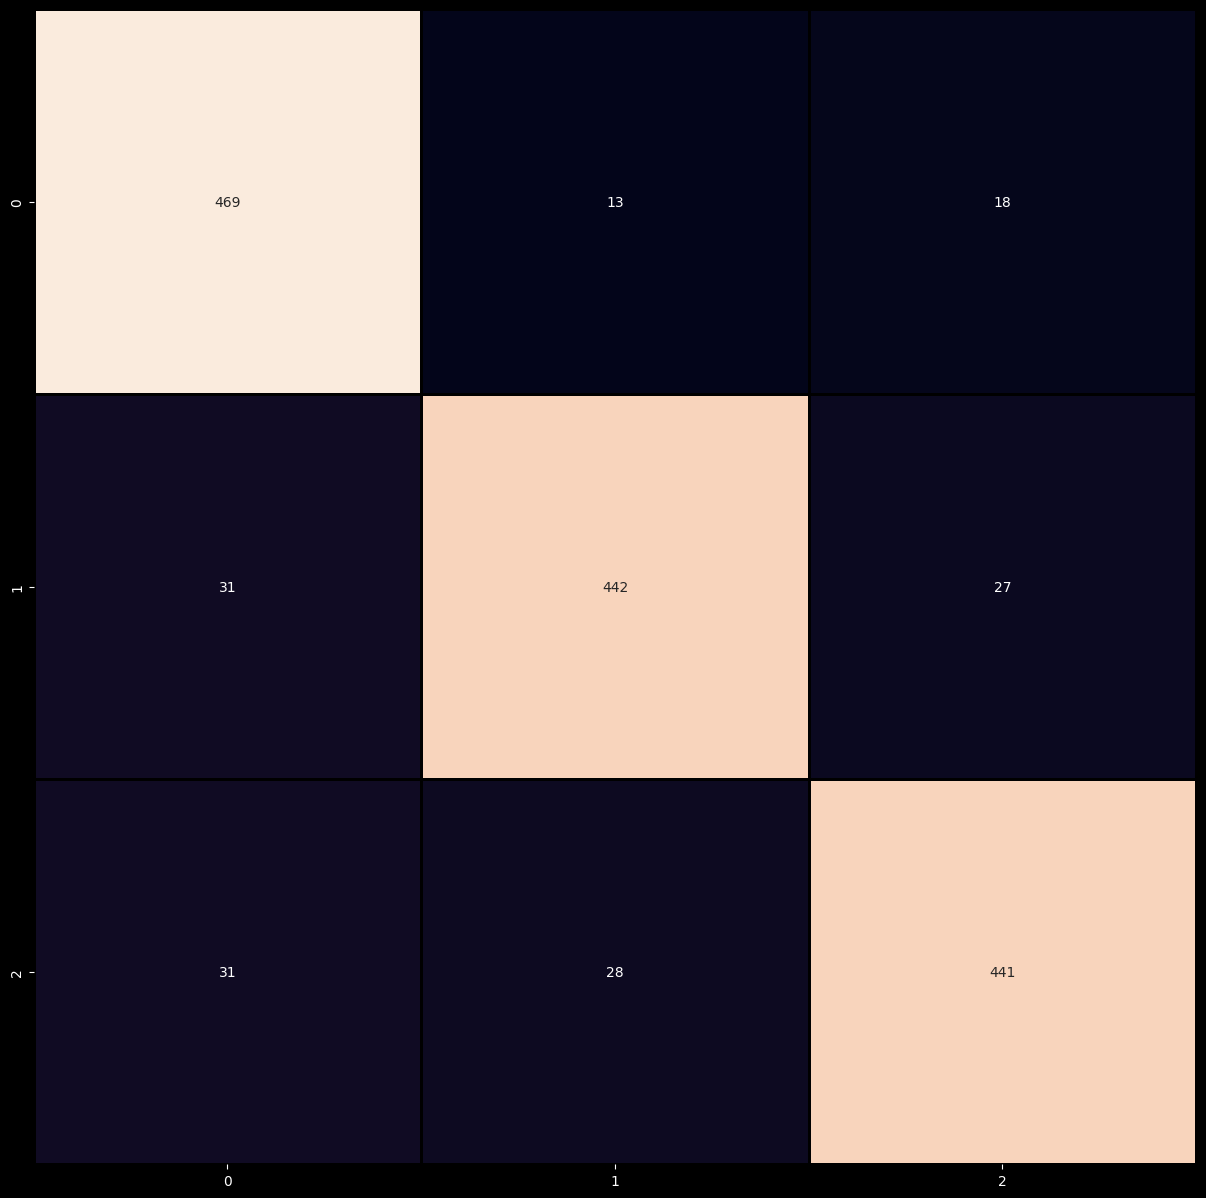

In [18]:
# finally print the confusion matrix for the best model: GradientBoostingClassifier

from sklearn.metrics import confusion_matrix
from seaborn import heatmap
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_hat)

plt.figure(figsize=(15, 15))
heatmap(data=cm, cbar=False, annot=True, fmt="d", linecolor="black", linewidths=2)
plt.show()